## PA005 - High Value Customer Identification (Rankers)

## 0.0 Planejamento da Soluçao (IOT)

### Input

🎯 Definição do Projeto – Programa Rankers

1️⃣ Problema de Negócio

Identificar e selecionar os clientes mais valiosos da base para compor o programa **Rankers**, priorizando aqueles com maior impacto no faturamento e maior potencial de retenção.

O objetivo é concentrar esforços estratégicos nos clientes que mais contribuem para o crescimento sustentável do negócio.

---

2️⃣ Conjunto de Dados

A análise foi realizada com base em:

- 📊 Dados de vendas de um e-commerce online  
- 📆 Período analisado: 1 ano  

Esses dados permitem avaliar comportamento de compra, frequência, recência e geração de receita.

### Output

1️⃣ Indicação dos Participantes

Entrega de uma lista objetiva contendo:

- Identificação do cliente  
- Status: **É Ranker? (Sim/Não)**  

Essa lista será a base oficial do programa.

---

2️⃣ Relatório Executivo

O relatório deverá responder às principais perguntas de negócio:

- Quem são as pessoas elegíveis ao programa?
- Quantos clientes farão parte do grupo?
- Quais são as principais características desses clientes?
- Qual a porcentagem de contribuição no faturamento total?
- Qual a expectativa de faturamento para os próximos meses?
- Quais são as condições para elegibilidade?
- Quais são as condições para remoção do programa?
- Qual a garantia de que o programa é superior ao restante da base?
- Quais ações de marketing podem aumentar o faturamento?

### Tasks

1️⃣ Quem são as pessoas elegíveis ao programa?

Definição de Elegibilidade

**📈 Faturamento**
- Alto ticket médio  
- Alto Lifetime Value (LTV)  
- Baixa recência (compras recentes)  
- Alto basket size  
- Baixa probabilidade de churn  
- Alta propensão de compra  

**💰 Custo**
- Baixa taxa de devolução  

**⭐ Experiência de Compra**
- Alta média de avaliação  

---

2️⃣ Quantos clientes farão parte do grupo?

- Número total de clientes elegíveis  
- Percentual que representam dentro da base  

---

3️⃣ Quais as principais características desses clientes?

**👤 Perfil Demográfico**
- Idade  
- Localização  
- Gênero  

**🛒 Perfil Comportamental**
- Atributos identificados na clusterização  

---

4️⃣ Qual a porcentagem de contribuição no faturamento?

- Faturamento total do ano  
- Faturamento gerado pelo grupo Ranker  
- Participação percentual do grupo na receita  

---

5️⃣ Qual a expectativa de faturamento futuro?

- Análise de LTV do grupo Ranker  
- Análise de Cohort para projeção de receita  

---

6️⃣ Condições para elegibilidade

- Definição de periodicidade de avaliação (mensal, bimestral, trimestral)  
- Similaridade com o perfil médio do grupo Ranker  

---

7️⃣ Condições para remoção

- Reavaliação periódica  
- Desvio significativo dos indicadores de valor  

---

8️⃣ Garantia de superioridade do programa

- Teste A/B comparando Rankers vs. base geral  
- Testes estatísticos de validação de impacto  

---

9️⃣ Ações estratégicas de marketing

- Relacionamento personalizado (ex: visita à empresa)  
- Benefícios exclusivos  
- Descontos estratégicos  

# 0.0 Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import inflection

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

## 0.1 Helper Functions

In [2]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")

vscode_settings()       

In [3]:
def plot_settings():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Base limpa
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Tamanho equilibrado
    plt.rcParams['figure.figsize'] = (14, 8)
    plt.rcParams['figure.dpi'] = 120
    
    # Fonte segura
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    # Grid mais leve
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'
    
    # Remove bordas desnecessárias
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Paleta mais profissional
    sns.set_palette("colorblind")
    
    # Pandas display
    pd.options.display.max_columns = None
    pd.options.display.max_rows = 200
    pd.set_option('display.expand_frame_repr', False)

plot_settings()

## 0.2 Load Dataset

In [4]:
df_raw = (
    pd.read_csv(
        '../data/Ecommerce.csv',
        encoding='latin1'
    )
    .loc[:, lambda df: ~df.columns.str.contains('^Unnamed')]
)

In [5]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


# 1.0 Data Description

In [6]:
df1 = df_raw

## 1.1 Rename columns

In [7]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [8]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
202061,554356,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,22-May-17,2.55,12670.0,France


## 1.2 Data Dimensions

In [9]:
df1.shape

(541909, 8)

## 1.3 Data types

In [10]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

## 1.4 Check NA

In [11]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## 1.5 Replace NA

In [12]:
# remove NA - Ciclo 1

df1 = df1.dropna(subset=['description', 'customer_id'])
print('Removed data: {:.2%}'.format( 1-(df1.shape[0] / df_raw.shape[0])))

Removed data: 24.93%


In [13]:
df1.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

## 1.6 Change dtypes

In [14]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

In [15]:
# invoice date

df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

#customer_id

df1['customer_id']  = df1['customer_id'].astype(int)

In [16]:
df1.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
dtype: object

## 1.7 Descriptive Statistics

# 2.0 Feature Engineering

In [17]:
df2 = df1.copy()

## 2.1 Feature Creation

In [18]:
df2.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [19]:
# data reference
df_ref = df2.drop(['invoice_no', 'stock_code', 'description', ''
                    'quantity', 'invoice_date', 'unit_price', 'country'], axis=1).drop_duplicates().reset_index(drop=True)
df_ref.head(10)

,customer_id
0,17850
1,13047
2,12583
3,13748
4,15100
5,15291
6,14688
7,17809
8,15311
9,14527


In [20]:
df2.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [21]:
# Gross Revenue quantity * price = faturamento
df2['gross_revenue'] = df2['quantity'] * df2['unit_price']

# Monetary
df_monetary = df2[['customer_id','gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge(df_ref, df_monetary, on='customer_id', how='left')

# Recency - Last day purchase
df_recency = df2[['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id', 'recency_days']].copy()

df_ref = pd.merge(df_ref, df_recency, on='customer_id', how='left')

# Frequency - Frequencia de Carrinhos / Compras finalizadas independente da quantidade de produtos em cada
df_freq = (df1.groupby('customer_id')['invoice_no'].nunique().reset_index().rename(columns={'invoice_no': 'frequency'}))
df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

In [22]:
df_ref.isna().sum()

customer_id      0
gross_revenue    0
recency_days     0
frequency        0
dtype: int64

In [23]:
df_ref.head()

,customer_id,gross_revenue,recency_days,frequency
0,17850,5288.63,302,35
1,13047,3079.10,31,18
2,12583,7187.34,2,18
3,13748,948.25,95,5
4,15100,635.10,330,6


# 3.0 Feature Filtering

In [24]:
df3 = df_ref.copy()

# 4.0 EDA

In [25]:
df4 = df3.copy()

# 5.0 Data Preparation

In [26]:
df5 = df4.copy()

# 6.0 Feature Selection

In [27]:
df6 = df5.copy()

In [28]:
df6.head()

,customer_id,gross_revenue,recency_days,frequency
0,17850,5288.63,302,35
1,13047,3079.10,31,18
2,12583,7187.34,2,18
3,13748,948.25,95,5
4,15100,635.10,330,6


# 7.0 Hyperparameter Fine-Tunning

In [29]:
df7 = df6.copy()

In [30]:
X = df7.drop(columns=['customer_id'])

In [31]:
clusters = [2,3,4,5,6,7,8,9,10,11]

## 7.1 Within-Cluster Sum of Square (WSS)

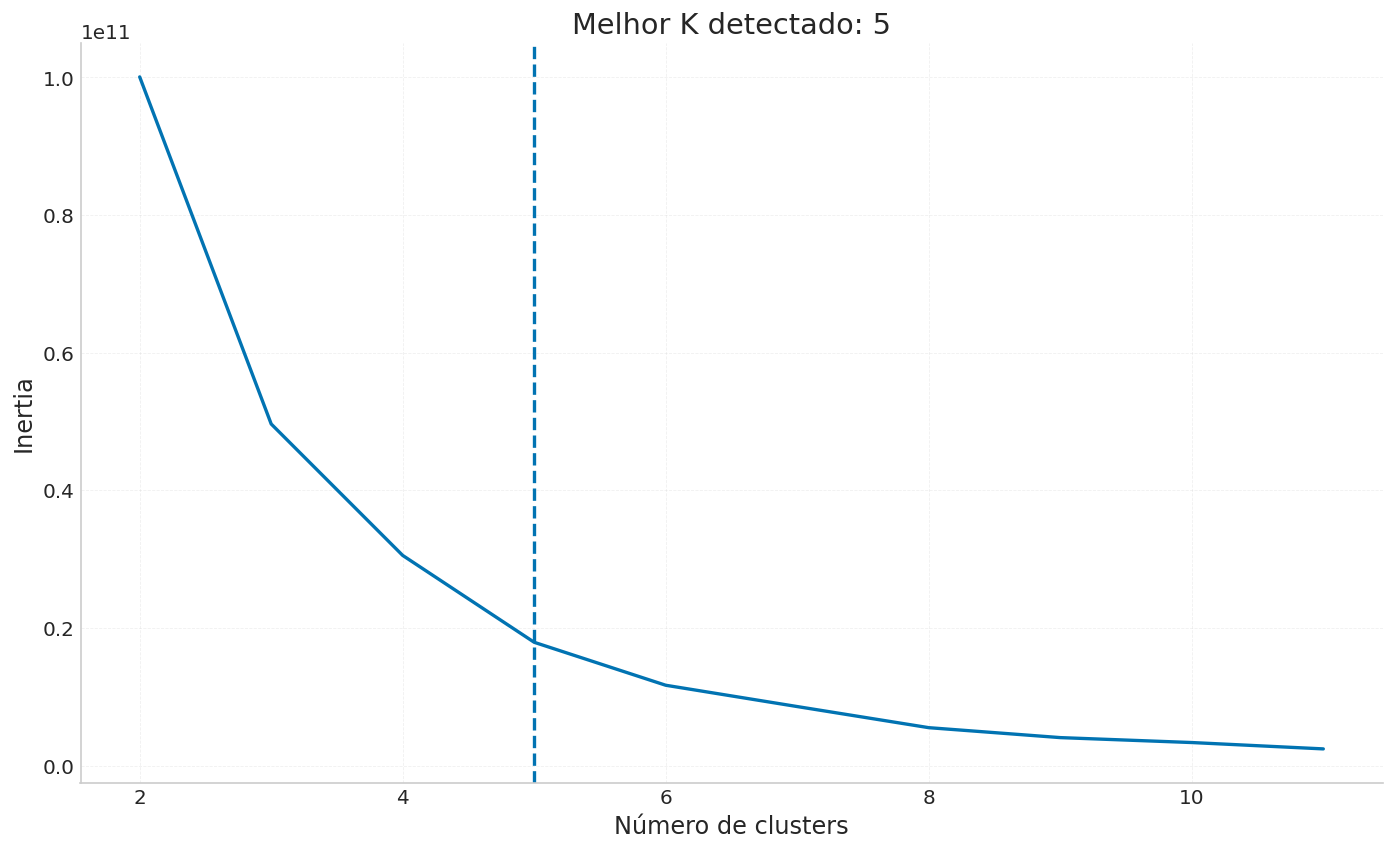

In [32]:
inertia = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Detectando o cotovelo
knee = KneeLocator(clusters, inertia, curve="convex", direction="decreasing")
best_k = knee.knee

# Plot
plt.plot(clusters, inertia)
plt.axvline(best_k, linestyle="--")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title(f"Melhor K detectado: {best_k}")
plt.show()

## 7.2 Silhouette Score

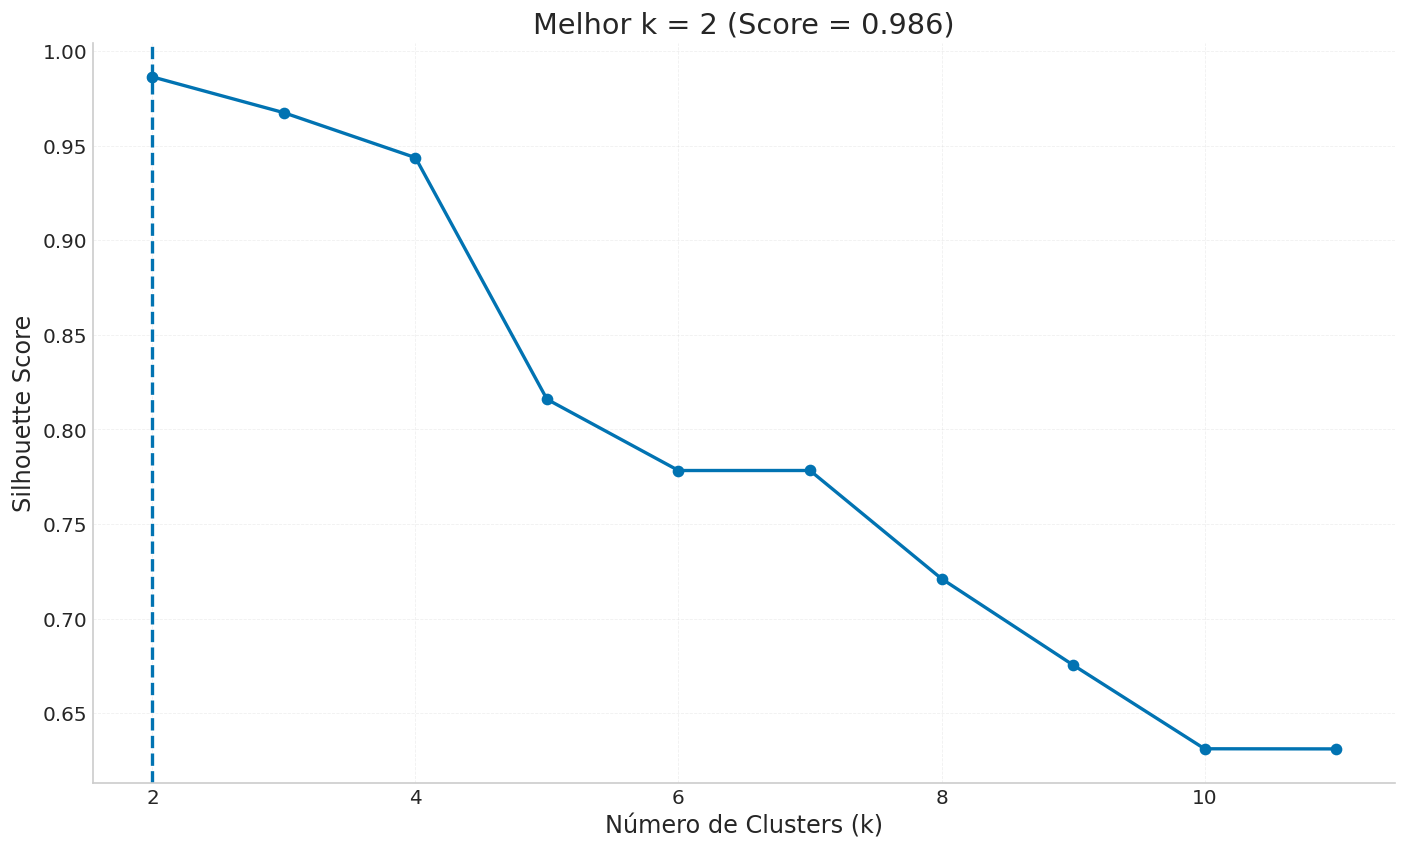

In [33]:
sil_scores = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Melhor k (maior silhouette)
best_index = np.argmax(sil_scores)
best_k = list(clusters)[best_index]
best_score = sil_scores[best_index]

# Plot
plt.plot(clusters, sil_scores, marker='o')
plt.axvline(best_k, linestyle='--')
plt.scatter(best_k, best_score)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title(f"Melhor k = {best_k} (Score = {best_score:.3f})")
plt.show()

# 8.0 Model Training

## 8.1 KMeans

In [34]:
k = 5
model = KMeans(init='random', n_clusters=k, n_init=10, max_iter=300)

model.fit(X)

labels = model.labels_

## 8.2 Cluster Validation

In [35]:
# WSS

print('WSS: {}'.format(model.inertia_))

# Silhouette
print('Silhouette: {}'.format(silhouette_score(X, labels, metric='euclidean')))

WSS: 22956286930.93179
Silhouette: 0.7734960328917805


# 9.0 Cluster Analysis

In [36]:
df6.head()

,customer_id,gross_revenue,recency_days,frequency
0,17850,5288.63,302,35
1,13047,3079.10,31,18
2,12583,7187.34,2,18
3,13748,948.25,95,5
4,15100,635.10,330,6


In [37]:
df9 = df6.copy()
df9['cluster'] = labels
df9.head()

,customer_id,gross_revenue,recency_days,frequency,cluster
0,17850,5288.63,302,35,2
1,13047,3079.10,31,18,0
2,12583,7187.34,2,18,2
3,13748,948.25,95,5,0
4,15100,635.10,330,6,0


## 9.1 Visualization

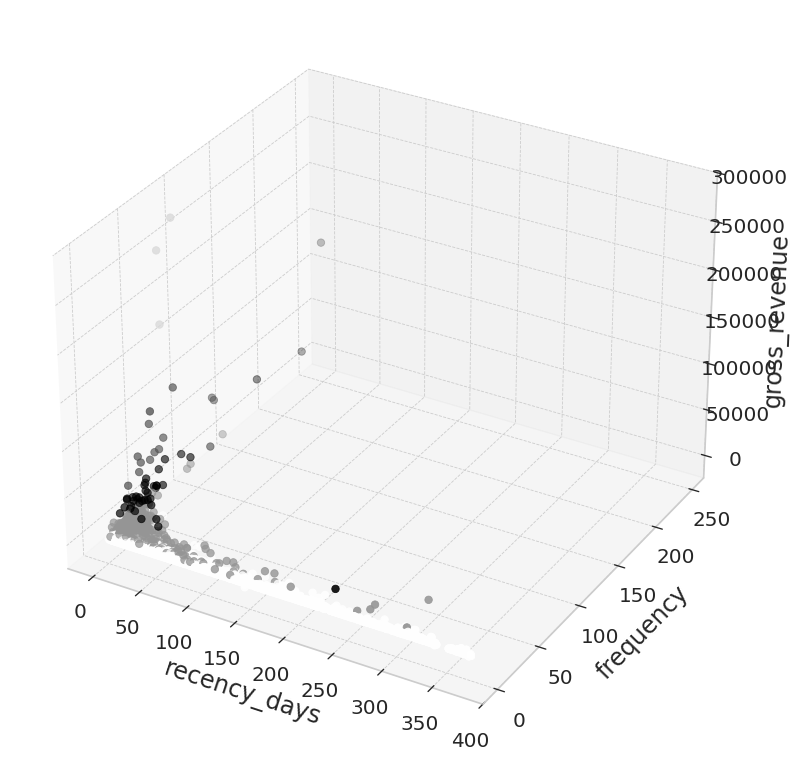

In [38]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    df9['recency_days'],
    df9['frequency'],
    df9['gross_revenue'],
    c=df9['cluster']
)

ax.set_xlabel('recency_days')
ax.set_ylabel('frequency')
ax.set_zlabel('gross_revenue')

plt.show()

## 9.2 Cluster Profile

In [39]:
df9.head()

,customer_id,gross_revenue,recency_days,frequency,cluster
0,17850,5288.63,302,35,2
1,13047,3079.10,31,18,0
2,12583,7187.34,2,18,2
3,13748,948.25,95,5,0
4,15100,635.10,330,6,0


In [47]:
df_cluster = (
    df9.groupby('cluster')
    .agg(
        customer_count      = ('customer_id', 'nunique'),
        total_gross_revenue = ('gross_revenue', 'sum'),
        avg_gross_revenue   = ('gross_revenue', 'mean'),
        avg_recency_days    = ('recency_days', 'mean'),
        avg_frequency       = ('frequency', 'mean'),
    )
    .reset_index()
)

df_cluster['perc_revenue'] = (
    100 * df_cluster['total_gross_revenue'] 
    / df_cluster['total_gross_revenue'].sum()
)

df_cluster_display = df_cluster.round(2)


df_cluster_display.sort_values('total_gross_revenue', ascending=False)

,cluster,customer_count,total_gross_revenue,avg_gross_revenue,avg_recency_days,avg_frequency,perc_revenue
0,0,3896,3186591.96,817.91,99.91,3.32,38.39
2,2,420,2437798.28,5804.28,25.12,15.23,29.37
3,3,15,1071352.74,71423.52,7.40,67.87,12.91
4,4,38,880913.15,23181.92,12.87,43.08,10.61
1,1,3,723409.68,241136.56,3.00,64.67,8.72


# 🏆 Análise de Candidatos a Rankers


🥇 Cluster 3 — Candidato Principal

🔥 **Recência média:** 7 dias  
🔁 **Frequência média:** 67 compras  
💰 **Ticket médio:** 71k  
👥 **Clientes:** 15  

> Grupo altamente ativo, recorrente e com alto valor.

---

🥈 Cluster 1 — Forte Candidato

🔥 **Recência média:** 3 dias  
🔁 **Frequência média:** 64 compras  
💰 **Ticket médio:** 241k  
👥 **Clientes:** 3  

> Pode representar **outliers de altíssimo valor**.

---

🥉 Cluster 4 — Muito Forte

🔥 **Recência média:** 12 dias  
🔁 **Frequência média:** 43 compras  
💰 **Ticket médio:** 23k  
👥 **Clientes:** 38  

> Grupo premium consistente, abaixo dos rankers

# 10.0 Deploy